In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn 


In [2]:
online_shoppers = pd.read_csv('online_shoppers_intention.csv')
online_shoppers


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


## Dataset Features Summary

| Feature | Type | Description |
|---|---|---|
| Administrative | Integer | Number of administrative pages (account, login, settings) visited in a session. |
| Administrative_Duration | Integer | Total time spent on administrative pages during the session. |
| Informational | Integer | Number of informational pages visited (FAQ, about, shipping information). |
| Informational_Duration | Integer | Total time spent on informational pages during the session. |
| ProductRelated | Integer | Number of product-related pages viewed during the session. |
| ProductRelated_Duration | Continuous | Total time spent browsing product-related pages. |
| BounceRates | Continuous | Percentage of visitors who leave the site after viewing only one page. |
| ExitRates | Continuous | Percentage of visits where a page was the last viewed in a session. |
| PageValues | Integer | Average value of a page based on its contribution to completed transactions. |
| SpecialDay | Integer | Indicates how close the visit time is to a special shopping day (higher means closer). |
| Month | Categorical | Month of the year when the visit occurred. |
| OperatingSystems | Integer | Encoded identifier of the visitor’s operating system. |
| Browser | Integer | Encoded identifier of the visitor’s web browser. |
| Region | Integer | Encoded geographic region of the visitor. |
| TrafficType | Integer | Encoded source of website traffic (direct, search, referral, etc.). |
| VisitorType | Categorical | Indicates whether the visitor is new or returning. |
| Weekend | Binary | Indicates whether the visit occurred on a weekend. |
| Revenue | Binary (Target) | Indicates whether the session resulted in a purchase. |



In [3]:
online_shoppers.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [4]:
online_shoppers.Revenue.value_counts()

Revenue
False    10422
True      1908
Name: count, dtype: int64

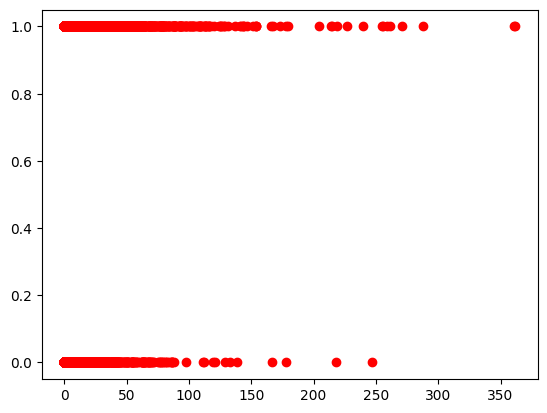

In [5]:
plt.scatter(online_shoppers.PageValues, online_shoppers.Revenue, color='red')

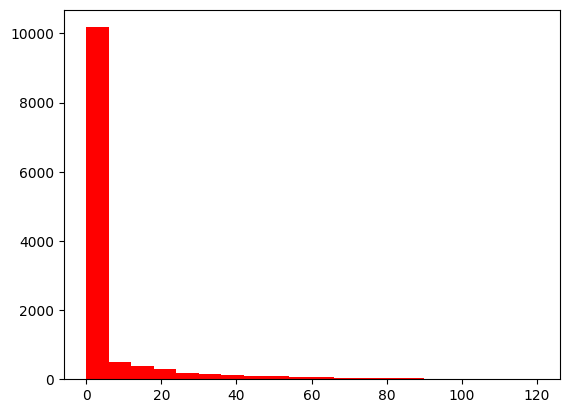

In [6]:
plt.hist(online_shoppers.PageValues, bins=20, range=[0, 120], color='red');


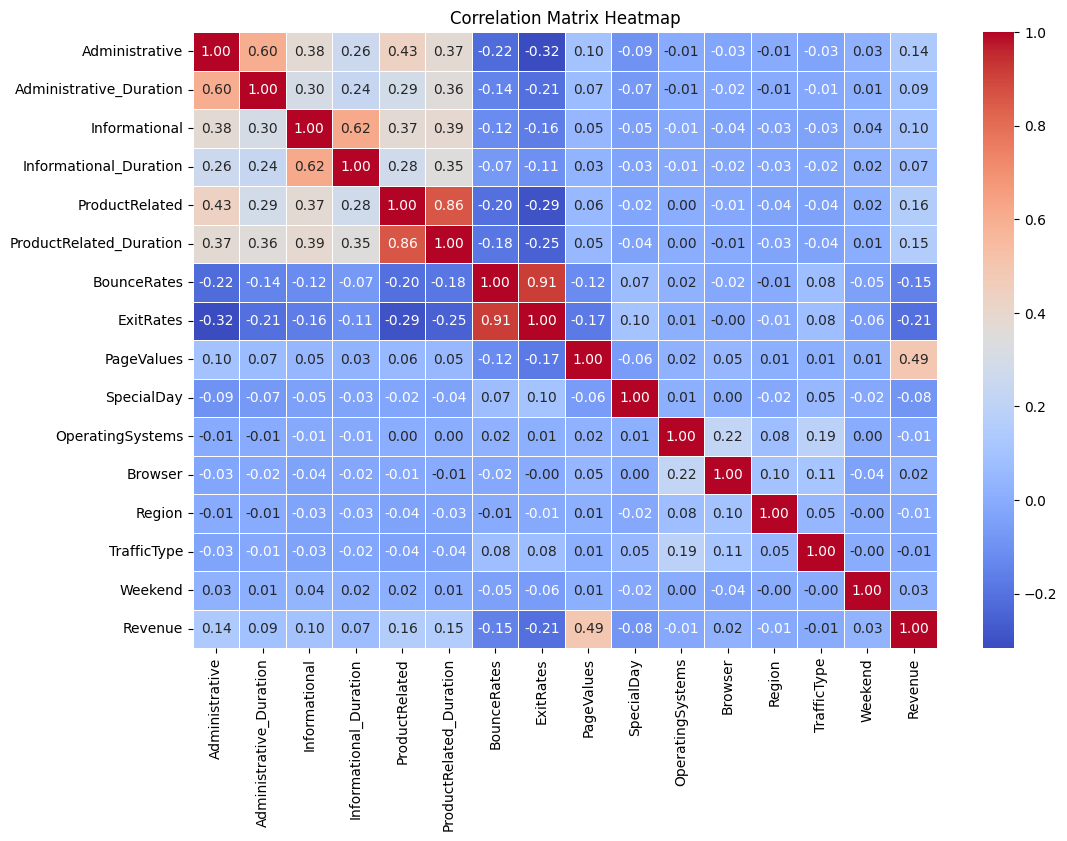

In [7]:
corr_matrix = online_shoppers.corr(numeric_only=True)
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,      # show numbers inside cells
    cmap="coolwarm", # color scheme (blue → red)
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix Heatmap")
plt.show()


Logistic Regression

In [8]:
categorical_cols = ["Month", "VisitorType"]
X = online_shoppers.drop(columns=["Revenue"] + categorical_cols)
y = online_shoppers["Revenue"]

Try one encoding later for categorical values

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.4, random_state=40)

logistic = LogisticRegression(max_iter=100000)
logistic.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100000
,multi_class,'deprecated'


## Logistic Regression with Categorical Features (Full Pipeline)


In [20]:


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

results = {}

for name, clf in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", clf)
        ]
    )
    
    cv_auc = cross_val_score(pipeline, X, y, cv=5, scoring="roc_auc")
    results[name] = cv_auc.mean()
    print(f"{name} Mean AUC: {cv_auc.mean():.4f}")

# Convert results to DataFrame for clean display
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Mean AUC'])
results_df = results_df.sort_values(by="Mean AUC", ascending=False)

print("\nModel Comparison:")
print(results_df)


Logistic Regression Mean AUC: 0.8601
Decision Tree Mean AUC: 0.7245
Random Forest Mean AUC: 0.9092
KNN Mean AUC: 0.7821

Model Comparison:
                     Mean AUC
Random Forest        0.909242
Logistic Regression  0.860066
KNN                  0.782107
Decision Tree        0.724484


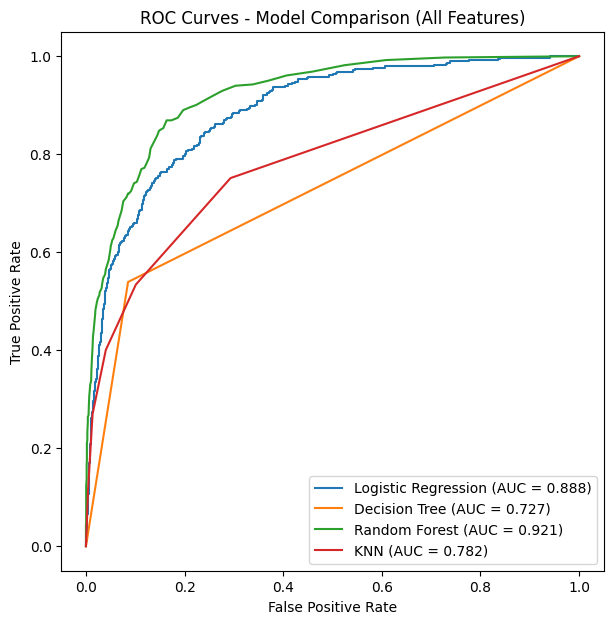

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

plt.figure(figsize=(7,7))

for name, clf in models.items():
    
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", clf)
        ]
    )
    
    pipeline.fit(X_train, y_train)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

# Diagonal baseline
#plt.plot([0, 1], [0, 1], "k--", label="Random Guess (AUC = 0.5)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison (All Features)")
plt.legend()
plt.show()